In [1]:
import os
os.environ['JAX_ENABLE_X64'] = '1'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.2' 

%matplotlib widget
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp

import numpy as np
from skimage.restoration import unwrap_phase
from temgym_core.components import Detector
from temgym_core.constants import wavelength2energy
from temgym_core.gaussian import circular_input_wave
from temgym_core.evaluate import evaluate_gaussians_for, evaluate_gaussians_gpu_kernel_wrapper
from temgym_core.gaussian import (
    KrivanekLens,
    run_to_end,
)
from temgym_core.aberrations import KrivanekCoeffs

jax.config.update("jax_enable_x64", True)

In [2]:
# Simulation Width
W = 0.01
Nx = Ny = 256
dx = W / Nx
dy = W / Ny
grid = Detector(z=0.0, pixel_size=(dx, dy), shape=(Nx, Ny))
coords = grid.coords
X, Y = coords[:, 0].reshape(grid.shape), coords[:, 1].reshape(grid.shape)
x = grid.coords_1d[0]
y = grid.coords_1d[1]
extent = grid.extent

# Aberrated Lens Parameters
f = 1
C_sph = 1.0
C_coma_x = -60.0
C_coma_y = 100.0
coeffs = KrivanekCoeffs(
    C30=C_sph,
    C21=C_coma_x, phi21=0.0,
    C23=C_coma_y, phi23=0.5 * jnp.pi,
)
lens = KrivanekLens(z=0.0, focal_length=f, coeffs=coeffs)

# Simulation wavelength and k number
wavelength = 0.00000075
k0 = 2 * np.pi / wavelength

# Optical path length surface of lens and its phase shift for this wavelength
opl_exact = np.real(jax.vmap(lens.phase_shift)(coords).reshape(grid.shape))
phase_exact = np.angle(np.exp(1j * k0 * jnp.real(opl_exact)).reshape(grid.shape))


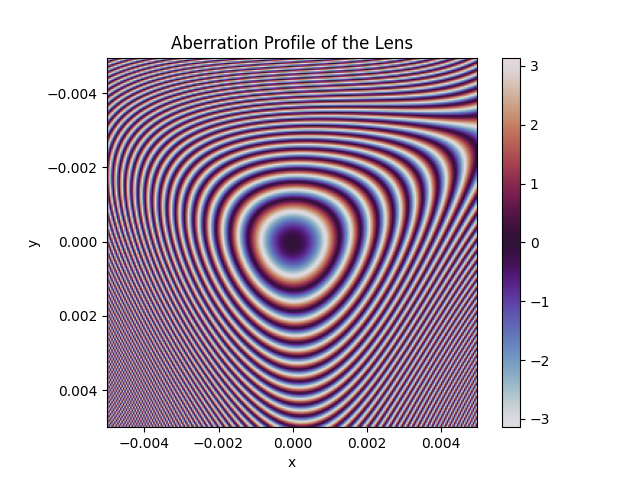

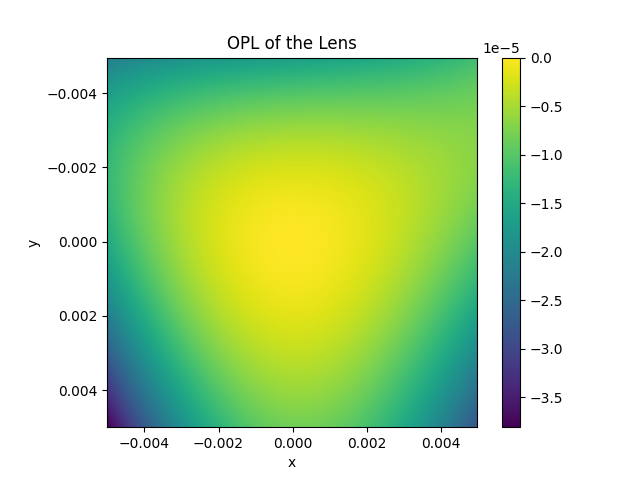

In [3]:
plt.figure()
plt.imshow(phase_exact, extent=extent, cmap='twilight', vmin=-np.pi, vmax=np.pi)
plt.title('Aberration Profile of the Lens')
plt.xlabel('x')
plt.ylabel('y')
plt.colorbar()

plt.figure()
plt.imshow(opl_exact, extent=extent, cmap='viridis')
plt.title('OPL of the Lens')
plt.xlabel('x')
plt.ylabel('y')
plt.colorbar()

In [4]:
voltage = wavelength2energy(wavelength)  # wavelength in meters as this function expects SI units
num_rays = 1
rx, ry = 0.0, 0.0
w0 = 1e-5  # Beam waist


ray_in = circular_input_wave(
    voltage=voltage,
    aperture_radius=1e-12,
    waist=w0,
)

ray_out = run_to_end(ray_in, [lens])

/home/dl277493/Microscope-Calibration/TemGymCore/src/temgym_core/utils.py:435: RuntimeWarning: invalid value encountered in sqrt
  radius * np.sqrt((ii + 0.5) / (nb_samples - 0.5 * (np_boundary + 1)))


In [5]:
E_gaussian = evaluate_gaussians_for(ray_out, grid)

In [6]:
phase_gaussian = np.angle(E_gaussian)
opl_gaussian = unwrap_phase(phase_gaussian) / ray_out.k

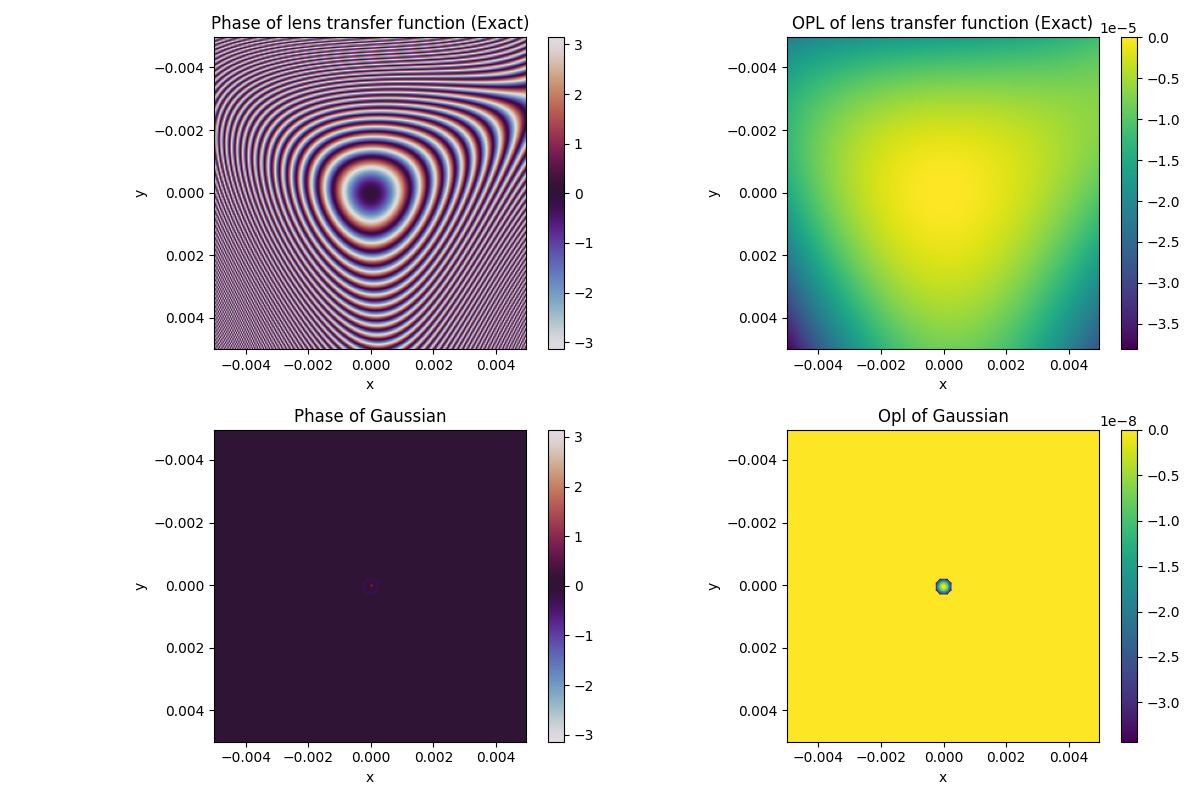

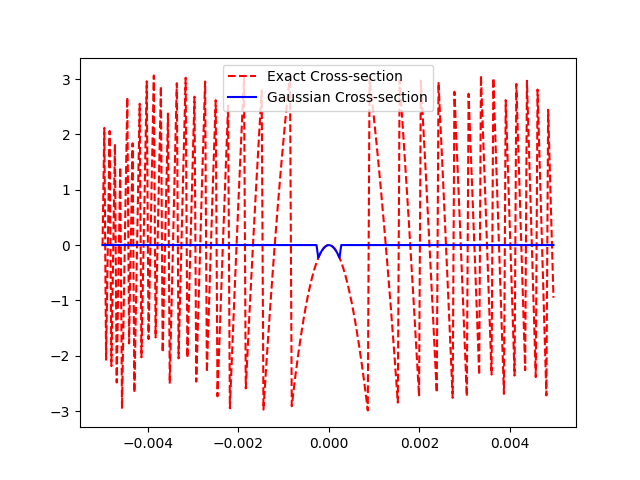

In [7]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# Phase of lens transfer function
im0 = axs[0, 0].imshow(phase_exact, extent=extent, cmap='twilight', vmin=-np.pi, vmax=np.pi)
axs[0, 0].set_title('Phase of lens transfer function (Exact)')
axs[0, 0].set_xlabel('x')
axs[0, 0].set_ylabel('y')
plt.colorbar(im0, ax=axs[0, 0], fraction=0.046, pad=0.04)

# Optical path length of lens transfer function
im1 = axs[0, 1].imshow(opl_exact, extent=extent, cmap='viridis')
axs[0, 1].set_title('OPL of lens transfer function (Exact)')
axs[0, 1].set_xlabel('x')
axs[0, 1].set_ylabel('y')
plt.colorbar(im1, ax=axs[0, 1], fraction=0.046, pad=0.04)

# Phase of Gaussian
im2 = axs[1, 0].imshow(phase_gaussian, extent=extent, cmap='twilight', vmin=-np.pi, vmax=np.pi)
axs[1, 0].set_title('Phase of Gaussian')
axs[1, 0].set_xlabel('x')
axs[1, 0].set_ylabel('y')
axs[1, 0].plot(ray_out.x, ray_out.y, 'r.', markersize=1)
plt.colorbar(im2, ax=axs[1, 0], fraction=0.046, pad=0.04)

# OPL of Gaussian
im3 = axs[1, 1].imshow(opl_gaussian, extent=extent, cmap='viridis')
axs[1, 1].set_title('Opl of Gaussian')
axs[1, 1].set_xlabel('x')
axs[1, 1].set_ylabel('y')
plt.colorbar(im3, ax=axs[1, 1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()
# Cross section plots of exact vs Gaussian
y_cross = Ny // 2
plt.figure()
plt.plot(x, phase_exact[y_cross, :], 'r--', label='Exact Cross-section')
plt.plot(x, phase_gaussian[y_cross, :], 'b-', label='Gaussian Cross-section')
plt.legend()

n_beams case

In [8]:
voltage = wavelength2energy(wavelength)
w0 = 1.0

rays_in = circular_input_wave(
    voltage=voltage,
    aperture_radius=W,
    waist=w0,
)
ray_out = run_to_end(rays_in, [lens])

In [9]:
E_gaussian = evaluate_gaussians_gpu_kernel_wrapper(ray_out, grid).block_until_ready()

In [10]:
phase_gaussian = np.angle(E_gaussian).reshape(grid.shape)
opl_gaussian = unwrap_phase(phase_gaussian) / ray_out.k

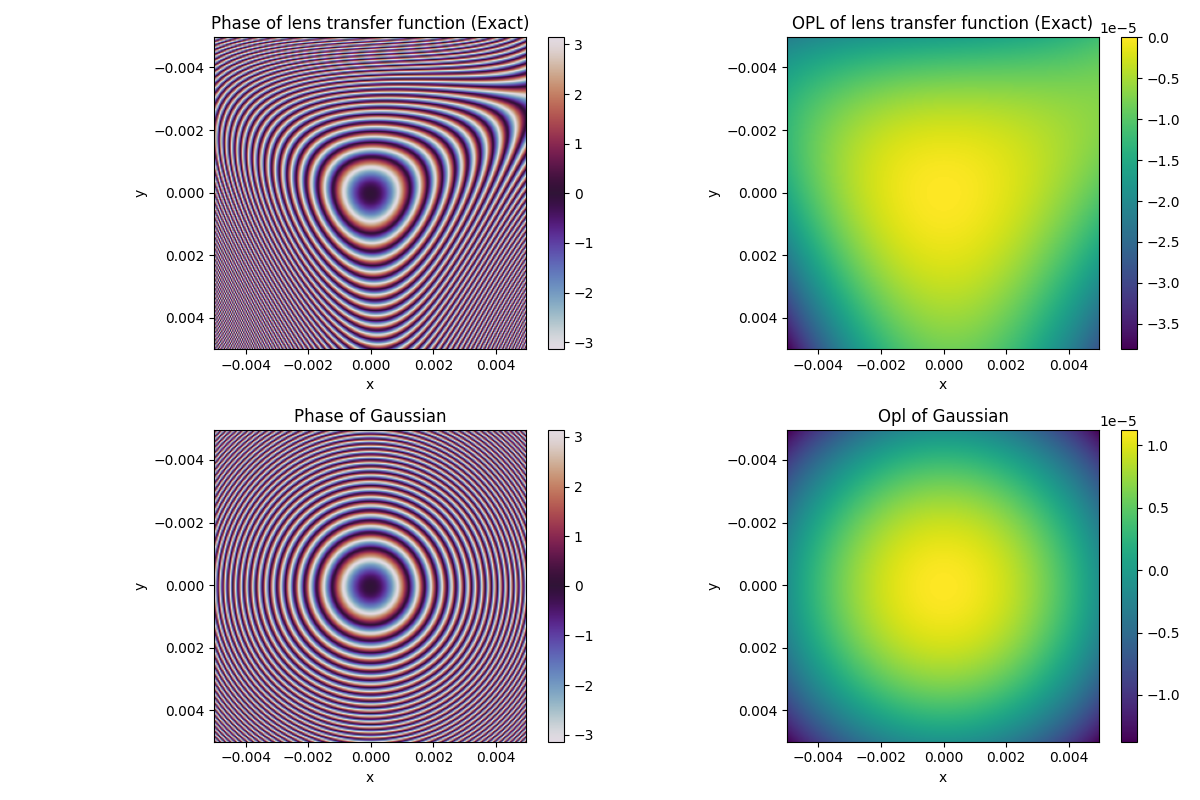

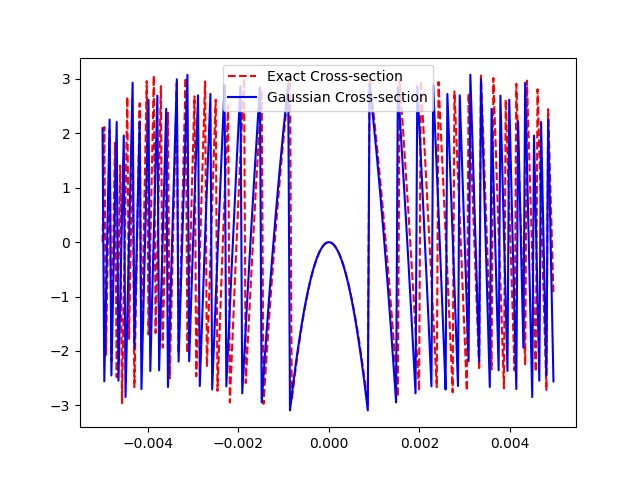

In [11]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# Phase of lens transfer function
im0 = axs[0, 0].imshow(phase_exact, extent=extent, cmap='twilight', vmin=-np.pi, vmax=np.pi)
axs[0, 0].set_title('Phase of lens transfer function (Exact)')
axs[0, 0].set_xlabel('x')
axs[0, 0].set_ylabel('y')
plt.colorbar(im0, ax=axs[0, 0], fraction=0.046, pad=0.04)

# Optical path length of lens transfer function
im1 = axs[0, 1].imshow(opl_exact, extent=extent, cmap='viridis')
axs[0, 1].set_title('OPL of lens transfer function (Exact)')
axs[0, 1].set_xlabel('x')
axs[0, 1].set_ylabel('y')
plt.colorbar(im1, ax=axs[0, 1], fraction=0.046, pad=0.04)

# Phase of Gaussian
im2 = axs[1, 0].imshow(phase_gaussian, extent=extent, cmap='twilight', vmin=-np.pi, vmax=np.pi)
axs[1, 0].set_title('Phase of Gaussian')
axs[1, 0].set_xlabel('x')
axs[1, 0].set_ylabel('y')
plt.colorbar(im2, ax=axs[1, 0], fraction=0.046, pad=0.04)

# OPL of Gaussian
im3 = axs[1, 1].imshow(opl_gaussian, extent=extent, cmap='viridis')
axs[1, 1].set_title('Opl of Gaussian')
axs[1, 1].set_xlabel('x')
axs[1, 1].set_ylabel('y')
plt.colorbar(im3, ax=axs[1, 1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()
# Cross section plots of exact vs Gaussian
y_cross = Ny // 2
plt.figure()
plt.plot(x, phase_exact[y_cross, :], 'r--', label='Exact Cross-section')
plt.plot(x, phase_gaussian[y_cross, :], 'b-', label='Gaussian Cross-section')
plt.legend()